In [1]:
import pandas as pd

# --- 1. Data Loading and Preprocessing (Modified for your format) ---
def load_and_preprocess_data(file_path_or_buffer):
    """
    Loads data from a CSV, pivots it into a wide format, and handles missing values.
    """
    print("🔄 Loading and preprocessing data...")
    df = pd.read_csv(file_path_or_buffer, sep=',')
    
    # Step 1: Create a single datetime index and sort
    df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['time']) + pd.to_timedelta(df['seconds'], unit='s')
    df = df.sort_values('timestamp').drop_duplicates()
    
    # Step 2: Pivot the DataFrame from long to wide format
    # Rows will be timestamps, columns will be sensors, values will be the 'state'
    wide_df = df.pivot_table(index='timestamp', columns='sensor_name', values='state', aggfunc='mean')
    
    # Step 3: Handle missing values using forward-fill
    # This carries the last known sensor state forward
    wide_df = wide_df.ffill().bfill() # bfill handles initial NaNs
    
    # Step 4: Convert to NumPy array
    sensor_names = wide_df.columns.tolist()
    data_array = wide_df.values
    
    print(f"✅ Data preprocessed successfully. Found {data_array.shape[1]} sensors.")
    return data_array, sensor_names

data_array, sensor_names = load_and_preprocess_data('Data\Home_Data\sead_anomaly_free_home_data_1h.csv')

<>:30: SyntaxWarning: invalid escape sequence '\H'
<>:30: SyntaxWarning: invalid escape sequence '\H'
C:\Users\mt5864s\AppData\Local\Temp\ipykernel_43816\326845549.py:30: SyntaxWarning: invalid escape sequence '\H'
  data_array, sensor_names = load_and_preprocess_data('Data\Home_Data\sead_anomaly_free_home_data_1h.csv')


🔄 Loading and preprocessing data...


C:\Users\mt5864s\AppData\Local\Temp\ipykernel_43816\326845549.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['date'] + ' ' + df['time']) + pd.to_timedelta(df['seconds'], unit='s')


✅ Data preprocessed successfully. Found 24 sensors.


In [7]:
print(f"Data shape: {data_array.shape}, {sensor_names} sensors loaded, sample data:\n{data_array[:5]}")

Data shape: (919, 3), ['Office Door Motion Sensor', 'Office Door Sensor', 'Office Light Sensor'] sensors loaded, sample data:
[[1. 1. 0.]
 [1. 1. 0.]
 [0. 1. 0.]
 [1. 1. 0.]
 [0. 1. 0.]]


In [ ]:

import numpy as np
import torch
# ============================================================
# COMPLEX ANOMALY INJECTION
# Six anomaly types distributed evenly across num_anomalies.
# Signature matches inject_selective_anomalies:
#   inject_complex_anomalies(data, edge_index, ...) -> (anomalous_data, labels)
#
# Types:
#   I.   Spike            – sensor → 1.0 for a random window
#   II.  Dropout          – sensor → 0.0 for a random window
#   III. Mixed            – 2-3 sensors, each randomly spiked or dropped, same window
#   IV.  Corr. violation  – two connected sensors forced to opposite extremes (8 steps)
#   V.   Neighbor incons  – sensor → opposite of neighbors' mean (5 steps)
#   VI.  Collective       – connected subgraph shifts opposite to boundary neighbors
# ============================================================

def inject_complex_anomalies(data, edge_index, num_anomalies=50,
                              min_duration=10, max_duration=40,
                              window_size=4, seed=None):
    """
    Injects a mixture of six anomaly types into the data.

    Parameters
    ----------
    data        : np.ndarray, shape (n_timesteps, n_sensors)
    edge_index  : torch.Tensor or array-like, shape (2, E) — graph adjacency
    num_anomalies : total anomalies to inject, distributed evenly across types
    min_duration  : minimum window length (floor-clamped to window_size)
    max_duration  : maximum window length (exclusive)
    window_size   : sliding window size; each anomaly spans >= this many steps
    seed          : optional numpy RNG seed for reproducibility

    Returns
    -------
    anomalous_data : np.ndarray, same shape as data
    labels         : np.ndarray, shape (n_timesteps,), 1 at anomalous timesteps
    """
    if seed is not None:
        np.random.seed(seed)

    n_steps, n_sensors = data.shape
    anomalous_data = data.copy().astype(np.float32)
    labels   = np.zeros(n_steps, dtype=np.float32)
    occupied = np.zeros(n_steps, dtype=bool)

    # ---- Build undirected adjacency list (self-loops excluded) ----
    _ei = (edge_index.cpu().numpy()
           if isinstance(edge_index, torch.Tensor)
           else np.array(edge_index))

    adj = {i: set() for i in range(n_sensors)}
    for k in range(_ei.shape[1]):
        s, d = int(_ei[0, k]), int(_ei[1, k])
        if s != d:
            adj[s].add(d)
            adj[d].add(s)

    undirected_edges = sorted({
        (min(s, d), max(s, d))
        for s in range(n_sensors)
        for d in adj[s]
    })
    sensors_w_neighbors = [s for s in range(n_sensors) if adj[s]]

    # ---- Distribute num_anomalies evenly across 6 types ----
    base   = num_anomalies // 6
    extras = num_anomalies % 6
    counts = [base + (1 if i < extras else 0) for i in range(6)]

    # Redistribute graph-based budgets if connectivity is insufficient
    if not undirected_edges:
        counts[0] += counts[3] + counts[4] + counts[5]
        counts[3] = counts[4] = counts[5] = 0
    elif not sensors_w_neighbors:
        counts[0] += counts[4] + counts[5]
        counts[4] = counts[5] = 0

    eff_min  = max(min_duration, window_size)
    MAX_ITER = num_anomalies * 25

    def _can_place(start, dur):
        return (start >= 0 and start + dur <= n_steps
                and not occupied[start:start + dur].any())

    def _mark(start, dur):
        labels[start:start + dur]   = 1
        occupied[start:start + dur] = True

    placed = [0] * 6

    # ---- I. Spike: sensor → 1.0 ----
    _t = 0
    while placed[0] < counts[0] and _t < MAX_ITER:
        _t += 1
        dur   = np.random.randint(eff_min, max(eff_min + 1, max_duration))
        start = np.random.randint(0, max(1, n_steps - dur))
        s     = np.random.randint(n_sensors)
        if _can_place(start, dur):
            anomalous_data[start:start + dur, s] = 1.0
            _mark(start, dur)
            placed[0] += 1

    # ---- II. Dropout: sensor → 0.0 ----
    _t = 0
    while placed[1] < counts[1] and _t < MAX_ITER:
        _t += 1
        dur   = np.random.randint(eff_min, max(eff_min + 1, max_duration))
        start = np.random.randint(0, max(1, n_steps - dur))
        s     = np.random.randint(n_sensors)
        if _can_place(start, dur):
            anomalous_data[start:start + dur, s] = 0.0
            _mark(start, dur)
            placed[1] += 1

    # ---- III. Mixed: 2-3 sensors, each randomly spiked or dropped ----
    _t = 0
    while placed[2] < counts[2] and _t < MAX_ITER:
        _t += 1
        dur   = np.random.randint(eff_min, max(eff_min + 1, max_duration))
        start = np.random.randint(0, max(1, n_steps - dur))
        n_aff = np.random.randint(2, min(4, n_sensors) + 1)
        sel   = np.random.choice(n_sensors, size=n_aff, replace=False)
        if _can_place(start, dur):
            for s in sel:
                anomalous_data[start:start + dur, s] = (
                    1.0 if np.random.random() > 0.5 else 0.0
                )
            _mark(start, dur)
            placed[2] += 1

    # ---- IV. Correlation violation: connected pair diverges around shared mean ----
    # Fixed 8-step window (floor-clamped to window_size).
    _iv_dur = max(8, window_size)
    _t = 0
    while placed[3] < counts[3] and _t < MAX_ITER and undirected_edges:
        _t += 1
        s_a, s_b = undirected_edges[np.random.randint(len(undirected_edges))]
        start    = np.random.randint(0, max(1, n_steps - _iv_dur))
        if _can_place(start, _iv_dur):
            # Shared mean in original data; diverge sensor_a up / sensor_b down (or vice versa)
            mean_ab = (data[start:start + _iv_dur, s_a].mean() +
                       data[start:start + _iv_dur, s_b].mean()) / 2.0
            if mean_ab >= 0.5:
                anomalous_data[start:start + _iv_dur, s_a] = 1.0
                anomalous_data[start:start + _iv_dur, s_b] = 0.0
            else:
                anomalous_data[start:start + _iv_dur, s_a] = 0.0
                anomalous_data[start:start + _iv_dur, s_b] = 1.0
            _mark(start, _iv_dur)
            placed[3] += 1

    # ---- V. Neighbor inconsistency: target → opposite of neighbors' mean ----
    # Fixed 5-step window (floor-clamped to window_size).
    _v_dur = max(5, window_size)
    _t = 0
    while placed[4] < counts[4] and _t < MAX_ITER and sensors_w_neighbors:
        _t += 1
        target    = sensors_w_neighbors[np.random.randint(len(sensors_w_neighbors))]
        neighbors = list(adj[target])
        start     = np.random.randint(0, max(1, n_steps - _v_dur))
        if _can_place(start, _v_dur):
            # Neighbor mean over the window (original data) — push target to the other extreme
            nb_mean = data[start:start + _v_dur, neighbors].mean()
            anomalous_data[start:start + _v_dur, target] = (
                0.0 if nb_mean >= 0.5 else 1.0
            )
            _mark(start, _v_dur)
            placed[4] += 1

    # ---- VI. Collective anomaly: connected subgraph shifts vs. boundary neighbors ----
    def _bfs_subgraph(root, size):
        """BFS: collect up to `size` connected nodes starting from `root`."""
        visited, queue = [root], [root]
        while len(visited) < size and queue:
            cur = queue.pop(0)
            for nb in adj[cur]:
                if nb not in visited:
                    visited.append(nb)
                    queue.append(nb)
                    if len(visited) >= size:
                        break
        return visited if len(visited) >= 2 else None

    _t = 0
    while placed[5] < counts[5] and _t < MAX_ITER and sensors_w_neighbors:
        _t += 1
        size     = np.random.randint(2, min(5, n_sensors + 1))
        root     = sensors_w_neighbors[np.random.randint(len(sensors_w_neighbors))]
        subgraph = _bfs_subgraph(root, size)
        if subgraph is None:
            continue
        sub_set  = set(subgraph)
        # External boundary: sensors connected to the subgraph but not in it
        boundary = {nb for s in subgraph for nb in adj[s] if nb not in sub_set}
        dur      = np.random.randint(eff_min, max(eff_min + 1, max_duration))
        start    = np.random.randint(0, max(1, n_steps - dur))
        if not _can_place(start, dur):
            continue
        # Reference direction from original data
        ref_nodes = list(boundary) if boundary else subgraph
        ref_mean  = data[start:start + dur, ref_nodes].mean()
        # Shift entire subgraph to the opposite extreme of the reference
        shift_val = 0.0 if ref_mean >= 0.5 else 1.0
        for s in subgraph:
            anomalous_data[start:start + dur, s] = shift_val
        _mark(start, dur)
        placed[5] += 1

    # ---- Summary ----
    type_names = [
        'I.   spike           ',
        'II.  dropout         ',
        'III. mixed           ',
        'IV.  corr_violation  ',
        'V.   neighbor_incons ',
        'VI.  collective      ',
    ]
    print("inject_complex_anomalies — results:")
    for name, p, c in zip(type_names, placed, counts):
        status = '' if p == c else f'  (WARNING: only {p}/{c} placed)'
        print(f"  {name}: {p:3d}/{c}{status}")
    total = sum(placed)
    if total < num_anomalies:
        print(f"  NOTE: {num_anomalies - total} anomalies could not be placed "
              f"(test segment too short or density too high)")
    print(f"  Total placed: {total}/{num_anomalies}  |  "
          f"Anomalous timesteps: {int(labels.sum())}")

    return anomalous_data, labels

In [49]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import GCNConv
from torch_geometric.nn.dense import DenseGCNConv
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import io

def inject_random_anomalies(data, num_anomalies=5, min_duration=20, max_duration=50):
    """Injects random anomalies into the dataset for evaluation."""
    print(f"💉 Injecting {num_anomalies} random anomalies...")
    anomalous_data = data.copy()
    labels = np.zeros(len(data))
    print(f"Data shape before anomaly injection: {data.shape}, anomalies to inject: {num_anomalies}")
    for _ in range(num_anomalies):
        duration = np.random.randint(min_duration, max_duration)
        start_idx = np.random.randint(0, len(data) - duration)
        sensor_idx = np.random.randint(0, data.shape[1])
        
        # Anomaly: sensor gets stuck ON (1) or OFF (0)
        stuck_value = np.random.choice([0, 1])
        anomalous_data[start_idx : start_idx + duration, :] = stuck_value
        # anomalous_data[start_idx : start_idx + duration, sensor_idx] = stuck_value # Affect one sensor

        labels[start_idx : start_idx + duration] = 1 # Mark these steps as anomalous
    
    print(f"anomalous data shape: {anomalous_data.shape}, labels shape: {labels.shape}")
    print(f"Number of anomalies injected: {np.sum(labels)}")
    return anomalous_data, labels

def inject_advanced_anomalies(data, a_type = "noise", num_anomalies=5):
    anomalous_data = data.copy()
    labels = np.zeros(len(data))
    num_sensors = data.shape[1]
    
    anomaly_types = ['noise', 'phase', 'scale', 'drift']
    
    for _ in range(num_anomalies):
        duration = np.random.randint(20, 50)
        start = np.random.randint(0, len(data) - duration)
        sensor_idx = np.random.randint(0, num_sensors)
        # a_type = np.random.choice(anomaly_types)
        
        if a_type == 'noise':
            anomalous_data[start:start+duration, sensor_idx] += np.random.normal(0, 2, duration)
        elif a_type == 'phase':
            # Shift by 15 steps
            shift = 15
            if start + duration + shift < len(data):
                anomalous_data[start:start+duration, sensor_idx] = data[start+shift:start+duration+shift, sensor_idx]
        elif a_type == 'scale':
            anomalous_data[start:start+duration, sensor_idx] *= 2.5
        elif a_type == 'drift':
            drift = np.linspace(0, 2, duration)
            anomalous_data[start:start+duration, sensor_idx] += drift
            
        labels[start:start+duration] = 1
        print(f"Injected {a_type} anomaly at index {start} for sensor {sensor_idx}")
        
    return anomalous_data, labels

# --- 2. New Function: Load and Synchronize Adjacency Matrix ---
def load_and_synchronize_adj_matrix(file_path_or_buffer, sensor_names):
    """
    Loads an adjacency matrix with named rows/columns and synchronizes its
    sensor order with the preprocessed data.
    """
    print("🔄 Loading and synchronizing adjacency matrix...")
    # Load the matrix, using the first column as the row index
    adj_df = pd.read_csv(file_path_or_buffer, sep=',', index_col=0)
    
    # Reindex to match the order of the sensor_names list
    # fill_value=0 ensures that any missing sensors are included with no connections
    adj_df_synced = adj_df.reindex(index=sensor_names, columns=sensor_names, fill_value=0)
    
    # Convert the synchronized DataFrame to a NumPy array
    adj_matrix = adj_df_synced.values
    print("✅ Adjacency matrix synchronized.")
    return adj_matrix

# --- Dataset Preparation (No changes needed) ---
def create_sliding_windows(data, window_size):
    sequences, targets = [], []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i + window_size])
        targets.append(data[i + window_size])
    return np.array(sequences), np.array(targets)

# --- 3. GNN Model Definitions ---

# OPTION A: Model that uses a PREDEFINED Adjacency Matrix
class SpatioTemporalGNN(nn.Module):
    def __init__(self, num_sensors, gcn_hidden_dim=16, rnn_hidden_dim=32):
        super(SpatioTemporalGNN, self).__init__()
        self.gcn = GCNConv(in_channels=1, out_channels=gcn_hidden_dim)
        self.rnn = nn.GRU(input_size=gcn_hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)

    def forward(self, x, edge_index):
        batch_size, window_size, num_sensors = x.shape
        gcn_out_seq = []
        for t in range(window_size):
            snapshot = x[:, t, :].reshape(-1, 1)
            batch_edge_index = edge_index.repeat(1, batch_size) + \
                               torch.arange(batch_size, device=x.device).repeat_interleave(edge_index.size(1)) * num_sensors
            gcn_out = self.gcn(snapshot, batch_edge_index)
            gcn_out = gcn_out.reshape(batch_size, num_sensors, -1)
            gcn_out_seq.append(gcn_out)
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        output = self.fc(graph_embedding)
        return output
    
# --- FIXED SpatioTemporalGNN with pre-computed batched edge_index ---
class SpatioTemporalGNN2(nn.Module):
    def __init__(self, num_sensors, gcn_hidden_dim=16, rnn_hidden_dim=32):
        super(SpatioTemporalGNN2, self).__init__()
        self.gcn = GCNConv(in_channels=1, out_channels=gcn_hidden_dim)
        self.rnn = nn.GRU(input_size=gcn_hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)

    def forward(self, x, edge_index):
        # x shape: (B, T, N)
        # edge_index shape: (2, E)
        
        batch_size, window_size, num_sensors = x.shape
        
        # --- THE FIX ---
        # The batched edge index is created ONCE, outside the loop.
        # This is massively faster.
        batch_edge_index = edge_index.repeat(1, batch_size) + \
                           torch.arange(batch_size, device=x.device).repeat_interleave(edge_index.size(1)) * num_sensors
        # --- END OF FIX ---

        gcn_out_seq = []
        for t in range(window_size):
            # Get the snapshot for this time step
            # Shape: (B, N) -> (B*N, 1)
            snapshot = x[:, t, :].reshape(-1, 1) 
            
            # Now this call is extremely fast, just using the pre-computed variable
            gcn_out = self.gcn(snapshot, batch_edge_index)
            
            # Reshape back to (B, N, D_h)
            gcn_out = gcn_out.reshape(batch_size, num_sensors, -1)
            gcn_out_seq.append(gcn_out)

        # Stack along the time dimension: (B, T, N, D_h)
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        
        # --- (Rest of the model is the same) ---
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        output = self.fc(graph_embedding)
        return output

# OPTION B: Model that LEARNS the Adjacency Matrix
# class GNN_LearnableGraph(nn.Module):
#     def __init__(self, num_sensors, hidden_dim=16, rnn_hidden_dim=32):
#         super(GNN_LearnableGraph, self).__init__()
#         self.num_sensors = num_sensors
#         self.adj_logits = nn.Parameter(torch.randn(num_sensors, num_sensors))
#         self.feature_transform = nn.Linear(1, hidden_dim)
#         self.rnn = nn.GRU(input_size=hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
#         self.fc = nn.Linear(rnn_hidden_dim, num_sensors)
#         # self.gcn = GCNConv(in_channels=1, out_channels=hidden_dim)
#         # self.rnn = nn.GRU(input_size=hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
#         # self.fc = nn.Linear(rnn_hidden_dim, num_sensors)
        
#     def forward(self, x):
#         batch_size, window_size, _ = x.shape
#         adj_matrix = torch.softmax(self.adj_logits, dim=1)
#         adj_matrix = adj_matrix * (1 - torch.eye(self.num_sensors, device=x.device))
#         gcn_out_seq = []
#         for t in range(window_size):
#             snapshot = x[:, t, :].unsqueeze(-1)
#             features = self.feature_transform(snapshot)
#             aggregated_features = torch.bmm(adj_matrix.unsqueeze(0).repeat(batch_size, 1, 1), features)
#             gcn_out_seq.append(aggregated_features)
#         gcn_outputs = torch.stack(gcn_out_seq, dim=1)
#         rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * self.num_sensors, window_size, -1)
#         _, h_n = self.rnn(rnn_input)
#         rnn_out = h_n.squeeze(0).reshape(batch_size, self.num_sensors, -1)
#         graph_embedding = rnn_out.mean(dim=1)
#         output = self.fc(graph_embedding)
#         return output

## learnable graph with dense gcn
class GNN_LearnableGraph(nn.Module):
    # MODIFICATION 1: Remove 'initial_adj_matrix' from the constructor
    def __init__(self, num_sensors, hidden_dim=16, rnn_hidden_dim=32):
        super(GNN_LearnableGraph, self).__init__()
        self.num_sensors = num_sensors
        
        # MODIFICATION 2: Initialize the adjacency matrix parameter randomly
        # This is the learnable graph, starting from scratch.
        self.adj_logits = nn.Parameter(torch.randn(num_sensors, num_sensors))

        self.gcn_layer = DenseGCNConv(in_channels=1, out_channels=hidden_dim)
        self.rnn = nn.GRU(input_size=hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)

    def forward(self, x):
        batch_size, window_size, _ = x.shape
        
        # The rest of the forward pass is identical
        adj_matrix = torch.softmax(self.adj_logits, dim=1)
        adj_matrix = adj_matrix * (1 - torch.eye(self.num_sensors, device=x.device))
        adj_batch = adj_matrix.unsqueeze(0).repeat(batch_size, 1, 1)
        
        gcn_out_seq = []
        for t in range(window_size):
            snapshot = x[:, t, :].unsqueeze(-1)
            gcn_out = self.gcn_layer(snapshot, adj_batch)
            gcn_out_seq.append(gcn_out)
            
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * self.num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, self.num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        output = self.fc(graph_embedding)
        return output

# OPTION C: Hybrid Model that gets an initial matrix and then LEARNS the Adjacency Matrix
class GNN_LearnableGraph_Initialized(nn.Module):
    # MODIFICATION 1: The constructor now takes an initial adjacency matrix
    def __init__(self, num_sensors, initial_adj_matrix, hidden_dim=16, rnn_hidden_dim=32):
        super(GNN_LearnableGraph_Initialized, self).__init__()
        self.num_sensors = num_sensors
        
        # MODIFICATION 2: Initialize the learnable parameter with the provided matrix
        self.adj_logits = nn.Parameter(torch.tensor(initial_adj_matrix, dtype=torch.float32))

        self.feature_transform = nn.Linear(1, hidden_dim)
        self.rnn = nn.GRU(input_size=hidden_dim, hidden_size=rnn_hidden_dim, batch_first=True)
        self.fc = nn.Linear(rnn_hidden_dim, num_sensors)
    def forward(self, x):
        batch_size, window_size, _ = x.shape
        adj_matrix = torch.softmax(self.adj_logits, dim=1)
        adj_matrix = adj_matrix * (1 - torch.eye(self.num_sensors, device=x.device))
        gcn_out_seq = []
        for t in range(window_size):
            snapshot = x[:, t, :].unsqueeze(-1)
            features = self.feature_transform(snapshot)
            aggregated_features = torch.bmm(adj_matrix.unsqueeze(0).repeat(batch_size, 1, 1), features)
            gcn_out_seq.append(aggregated_features)
        gcn_outputs = torch.stack(gcn_out_seq, dim=1)
        rnn_input = gcn_outputs.permute(0, 2, 1, 3).reshape(batch_size * self.num_sensors, window_size, -1)
        _, h_n = self.rnn(rnn_input)
        rnn_out = h_n.squeeze(0).reshape(batch_size, self.num_sensors, -1)
        graph_embedding = rnn_out.mean(dim=1)
        output = self.fc(graph_embedding)
        return output

In [4]:
import torch
import gc

def clear_gpu_memory():
    # 1. Delete variables that might be holding onto GPU tensors
    # You may need to manually del large tensors like: del model, sequences, targets
    
    # 2. Trigger Python's garbage collector
    gc.collect()
    
    # 3. Clear the PyTorch CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        print("Done! CUDA cache cleared.")

# Usage
clear_gpu_memory()

Done! CUDA cache cleared.


🔄 Loading and synchronizing adjacency matrix...
✅ Adjacency matrix synchronized.
💉 Injecting 20 random anomalies...
Data shape before anomaly injection: (184, 3), anomalies to inject: 20
anomalous data shape: (184, 3), labels shape: (184,)
Number of anomalies injected: 174.0
🗺️ Training with PREDEFINED graph structure...
Epoch 10/400, Average Loss: 0.690761
Epoch 20/400, Average Loss: 0.683112
Epoch 30/400, Average Loss: 0.675178
Epoch 40/400, Average Loss: 0.666887
Epoch 50/400, Average Loss: 0.658048
Epoch 60/400, Average Loss: 0.648570
Epoch 70/400, Average Loss: 0.638580
Epoch 80/400, Average Loss: 0.628107
Epoch 90/400, Average Loss: 0.616973
Epoch 100/400, Average Loss: 0.605398
Epoch 110/400, Average Loss: 0.593419
Epoch 120/400, Average Loss: 0.581214
Epoch 130/400, Average Loss: 0.568869
Epoch 140/400, Average Loss: 0.556719
Epoch 150/400, Average Loss: 0.545159
Epoch 160/400, Average Loss: 0.533852
Epoch 170/400, Average Loss: 0.524060
Epoch 180/400, Average Loss: 0.514677
Ep

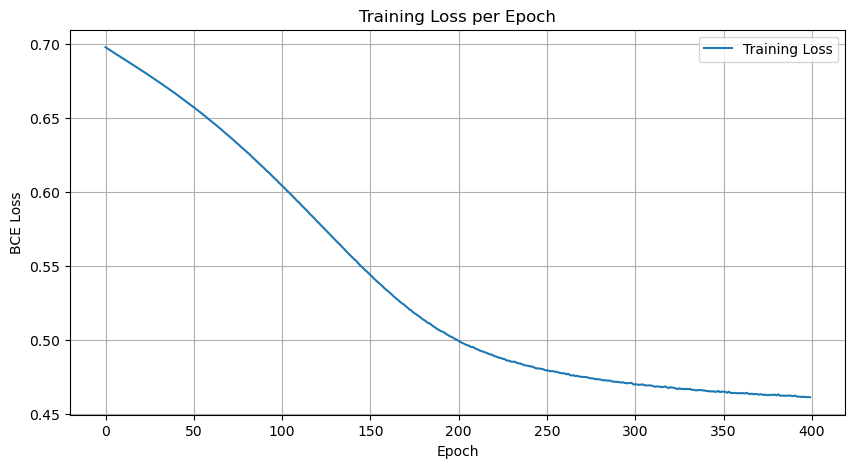

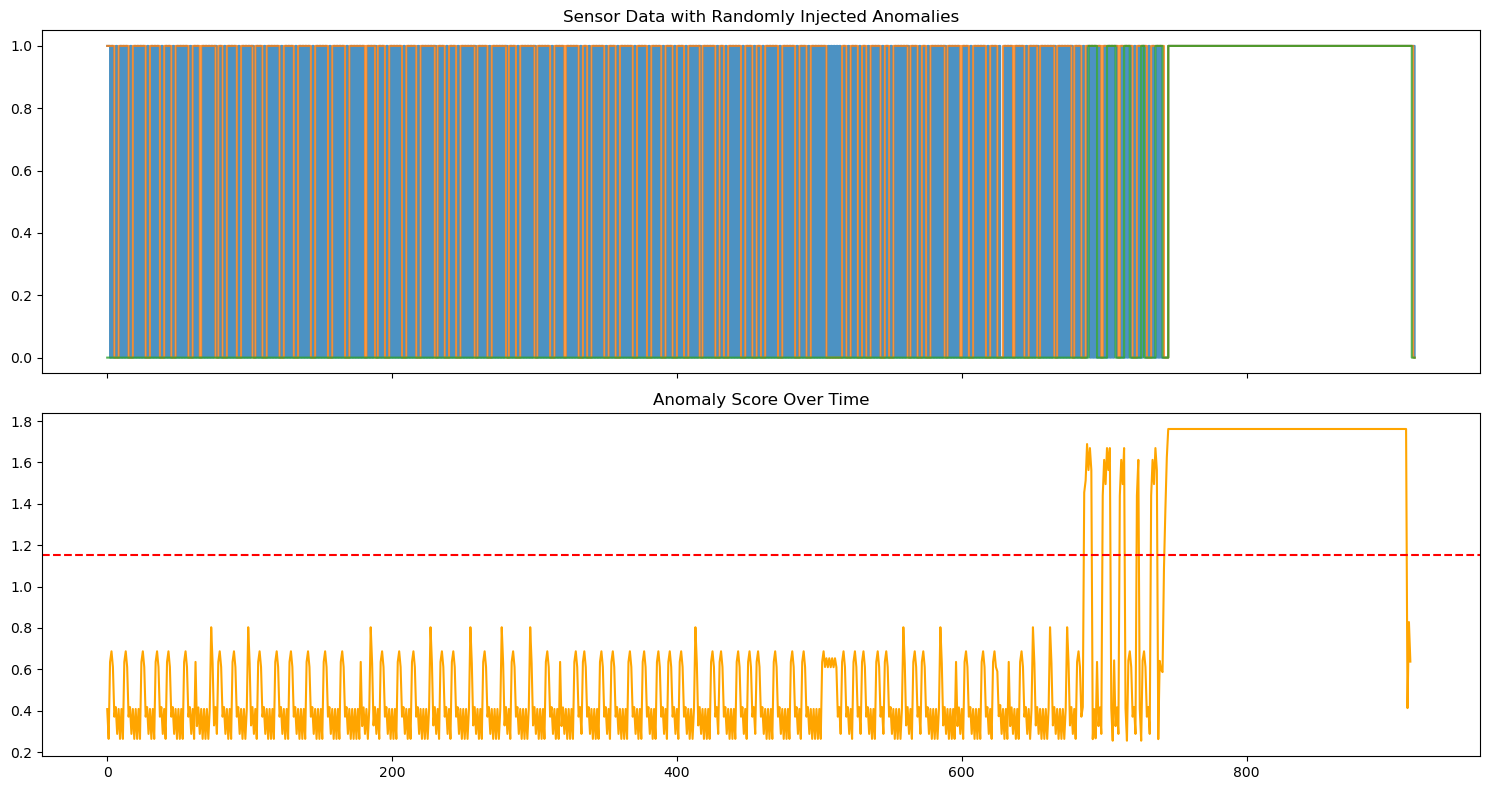

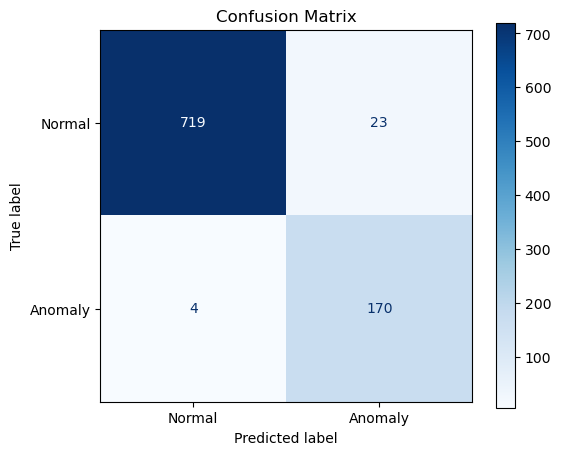

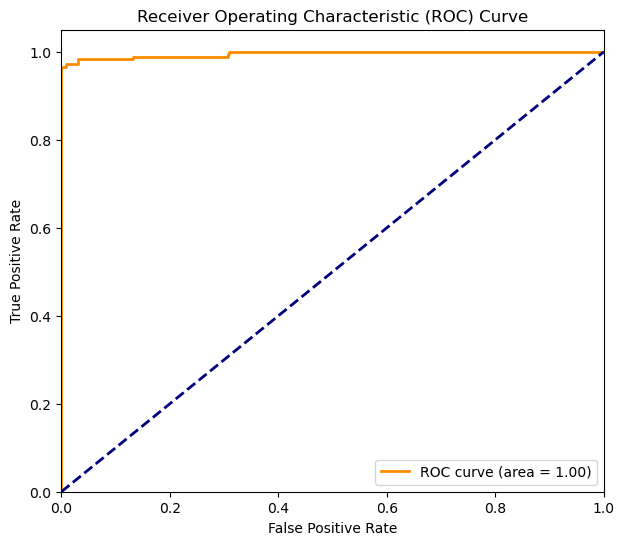

In [ ]:
# --- Main Execution ---
if __name__ == '__main__':
    # --- Create a sample CSV in memory to simulate your file ---
#     sample_csv_data = """date;time;seconds;state;sensor_name;thing_name;thing_ip;thing_ip0
# 2025-09-16;15:00;0;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;0;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;0;0;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;1;1;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;1;0;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;1;0;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;2;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;2;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;2;1;SENSOR_C;device2;192.168.1.11;eth0
# 2025-09-16;15:00;3;0;SENSOR_A;device1;192.168.1.10;eth0
# 2025-09-16;15:00;3;1;SENSOR_B;device1;192.168.1.10;eth0
# 2025-09-16;15:00;3;0;SENSOR_C;device2;192.168.1.11;eth0
# """
#     # In your real code, you would use: file_path = "your_data.csv"
#     csv_buffer = io.StringIO(sample_csv_data)
    
    # Load and process the data
    # data, sensor_names = load_and_preprocess_data(csv_buffer)
    # --- Configuration ---
    # 💡 SET THIS TO True OR False TO SWITCH MODELS
    LEARN_GRAPH = False 
    
    

    # Inject random anomalies to create the full dataset and ground truth labels
    # data, ground_truth_labels = inject_random_anomalies(data_array, num_anomalies=100)
    regular_data = data_array ## Original normal data
    NUM_SENSORS = regular_data.shape[1]
    WINDOW_SIZE = NUM_SENSORS
    # NUM_SENSORS = data_array.shape[1]
    # adj_csv_buffer = pd.read_csv('Data/adjacency_matrices/fne_matrix_norm.csv')
    adj_matrix = load_and_synchronize_adj_matrix('Data/adjacency_matrices/home_fne_matrix_norm.csv', sensor_names)
    # adj_matrix =[[]]

    edge_index = torch.tensor(np.array(np.where(adj_matrix)), dtype=torch.long)

    # --- Data Splitting and Preparation ---
    TRAIN_SPLIT = int(len(regular_data) * 0.8) # Use first 80% for training
    train_data = regular_data[:TRAIN_SPLIT] # Training data is always normal

    # Test data includes anomalies
    test_data = regular_data[TRAIN_SPLIT:]
    test_data_anomalies, test_truth_labels = inject_random_anomalies(test_data, num_anomalies=20)

    ## Combine train and test data for evaluation
    data = np.vstack([train_data, test_data_anomalies])
    ground_truth_labels = np.hstack([np.zeros(len(train_data)), test_truth_labels])
    
    sequences, targets = create_sliding_windows(train_data, WINDOW_SIZE)
    train_dataset = TensorDataset(torch.tensor(sequences, dtype=torch.float32), 
                                  torch.tensor(targets, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # --- Model Selection and Training ---
    if LEARN_GRAPH:
        print("🧠 Training with LEARNABLE graph structure...")
        model = GNN_LearnableGraph(num_sensors=NUM_SENSORS)
    else:
        print("🗺️ Training with PREDEFINED graph structure...")
        model = SpatioTemporalGNN2(num_sensors=NUM_SENSORS)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)
    criterion = nn.BCEWithLogitsLoss()
    # criterion = nn.MSELoss()

    # Create a list to store loss history
    loss_history = []
    epochs = 400
    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0
        for seq, target in train_loader:
            optimizer.zero_grad()
            if LEARN_GRAPH:
                output_logits = model(seq)
            else:
                output_logits = model(seq, edge_index)
            loss = criterion(output_logits, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1
        
        # MODIFICATION 2: Save the average loss for the epoch
        avg_epoch_loss = epoch_loss / num_batches
        loss_history.append(avg_epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_epoch_loss:.6f}")

    print("✅ Training complete.")

    # --- Inference and Anomaly Scoring ---
    model.eval()
    all_sequences, all_targets = create_sliding_windows(data, WINDOW_SIZE)
    with torch.no_grad():
        if LEARN_GRAPH:
            prediction_logits = model(torch.tensor(all_sequences, dtype=torch.float32))
        else:
            prediction_logits = model(torch.tensor(all_sequences, dtype=torch.float32), edge_index)

    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    # loss_fn = nn.MSELoss(reduction='none')
    anomaly_scores = loss_fn(prediction_logits, torch.tensor(all_targets, dtype=torch.float32)).mean(axis=1).numpy()
    
    # Determine threshold from normal training data
    train_scores = anomaly_scores[:len(train_data) - WINDOW_SIZE]
    threshold = np.mean(train_scores) + 3 * np.std(train_scores)

    # --- 📊 Evaluation Section 📊 ---
    print("\n--- Model Evaluation ---")
    
    # Align predictions with ground truth labels
    # Predictions start after the first window
    test_predictions = (anomaly_scores > threshold).astype(int)
    test_ground_truth = ground_truth_labels[WINDOW_SIZE:]

    # Calculate metrics
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        test_ground_truth, test_predictions, average='binary'
    )
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1_score:.4f}")

    # MODIFICATION 3: Add a plot for the training loss
    fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
    ax_loss.plot(loss_history, label='Training Loss')
    ax_loss.set_title('Training Loss per Epoch')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('BCE Loss')
    ax_loss.legend()
    ax_loss.grid(True)

    # --- Plotting ---
    # 1. Plot Sensor Data and Anomaly Scores
    fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    ax1.plot(data, alpha=0.8, drawstyle='steps-post')
    ax1.set_title("Sensor Data with Randomly Injected Anomalies")
    ax2.plot(anomaly_scores, color='orange', label='Anomaly Score (BCE Loss)')
    ax2.axhline(threshold, color='red', linestyle='--', label='Threshold')
    ax2.set_title("Anomaly Score Over Time")
    plt.tight_layout()
    
    # 2. Plot Confusion Matrix
    cm = confusion_matrix(test_ground_truth, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    fig2, ax_cm = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax_cm, cmap='Blues')
    ax_cm.set_title('Confusion Matrix')

    # 3. Plot ROC Curve
    fpr, tpr, _ = roc_curve(test_ground_truth, anomaly_scores)
    roc_auc = auc(fpr, tpr)
    fig3, ax_roc = plt.subplots(figsize=(7, 6))
    ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax_roc.legend(loc="lower right")
    # plt.savefig('./Plots/Graph-Learning/roc-graph-no-learning.png', dpi=300)

    savefigs = [fig_loss, fig1, fig2, fig3]
    for i, fig in enumerate(savefigs, 1):
        fig.savefig(f'./Plots/Graph-No-Learning/Office/gnn_model_2_evaluation_plot_BCE_Loss_{i}_epoch400.png')
    plt.show()

🔄 Loading and synchronizing adjacency matrix...
✅ Adjacency matrix synchronized.
💉 Injecting 50 random anomalies...
Data shape before anomaly injection: (6640, 10), anomalies to inject: 50
anomalous data shape: (6640, 10), labels shape: (6640,)
Number of anomalies injected: 1539.0
🧠 Training with HYBRID (Initialize & Fine-Tune) graph structure...
🚀 Starting model training...
Epoch 10/100, Average Loss: 0.184862
Epoch 20/100, Average Loss: 0.170257
Epoch 30/100, Average Loss: 0.164516
Epoch 40/100, Average Loss: 0.164206
Epoch 50/100, Average Loss: 0.163609
Epoch 60/100, Average Loss: 0.161975
Epoch 70/100, Average Loss: 0.183101
Epoch 80/100, Average Loss: 0.187420
Epoch 90/100, Average Loss: 0.176323
Epoch 100/100, Average Loss: 0.169965
✅ Training complete.

--- Model Evaluation ---
Precision: 0.1805
Recall:    0.1501
F1-Score:  0.1639


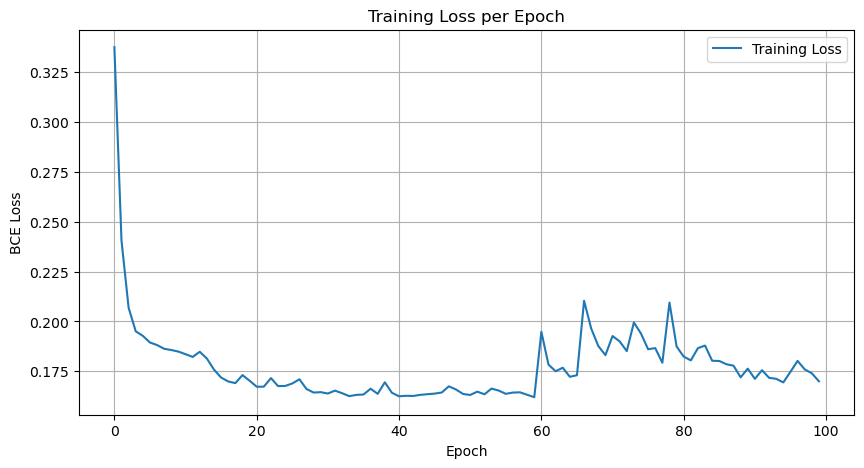

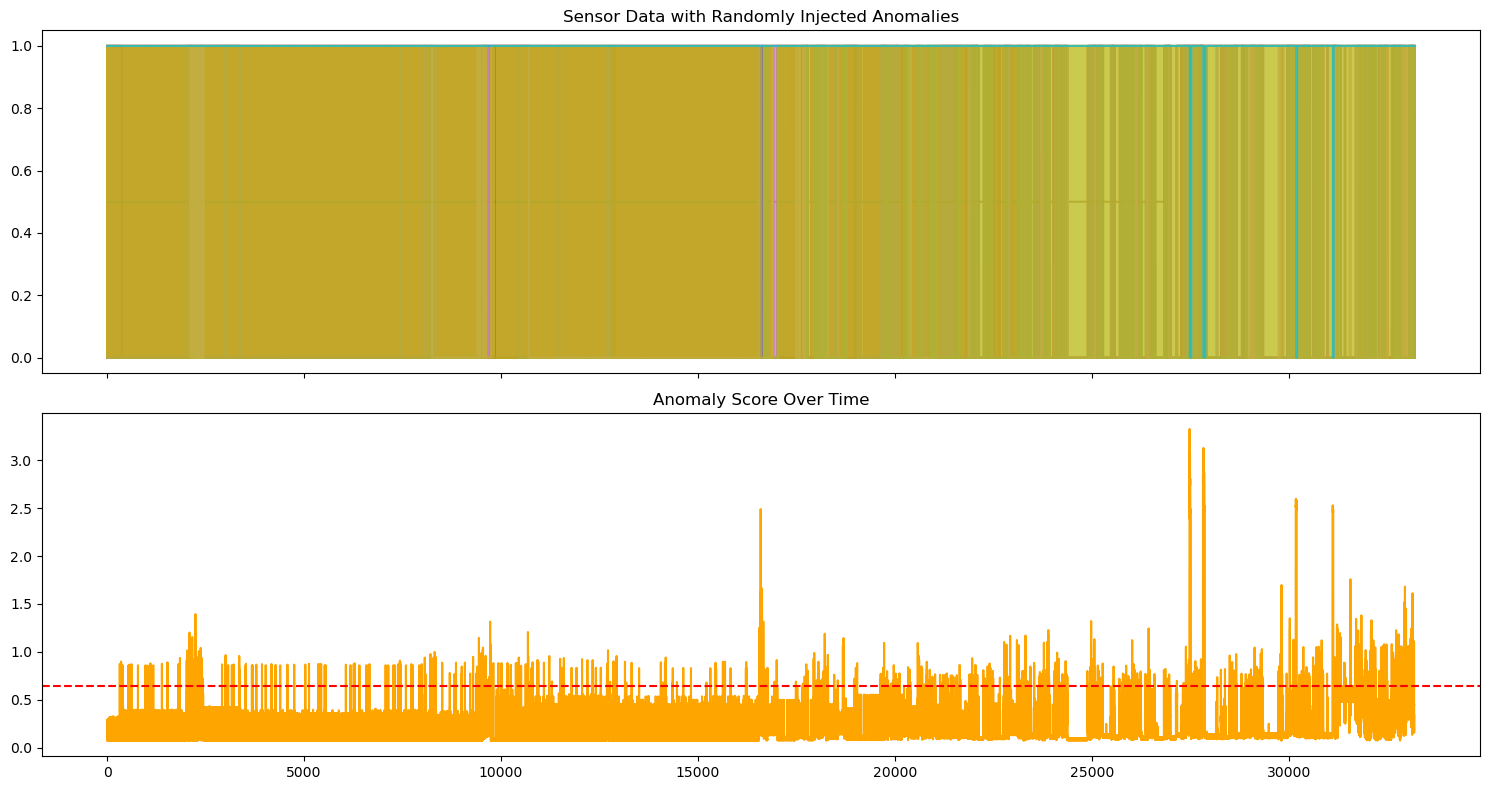

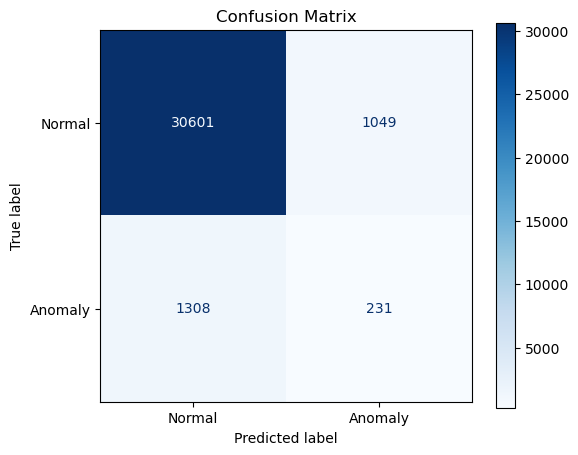

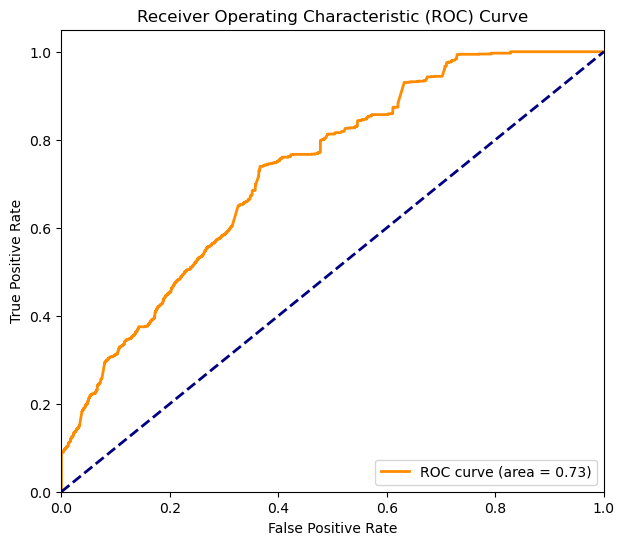

In [ ]:
if __name__ == '__main__':
    # --- Device Configuration ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    normal_data_base = data_array  # Use the preprocessed data from earlier
    NUM_SENSORS = normal_data_base.shape[1]
    
    # --- Adjacency Matrix and Edge Index Preparation ---
    predefined_adj_matrix = load_and_synchronize_adj_matrix('Data/adjacency_matrices/home_fne_matrix_norm.csv', sensor_names)

    # --- Data Splitting ---
    TRAIN_SPLIT = int(len(normal_data_base) * 0.8) 
    train_data = normal_data_base[:TRAIN_SPLIT]
    test_data_normal = normal_data_base[TRAIN_SPLIT:]
    test_data_anomalies, test_labels = inject_random_anomalies(test_data_normal, num_anomalies=50)
    data = np.concatenate((train_data, test_data_anomalies), axis=0)
    ground_truth_labels = np.concatenate((np.zeros(len(train_data)), test_labels), axis=0)
    
    sequences, targets = create_sliding_windows(train_data, NUM_SENSORS)
    train_dataset = TensorDataset(torch.tensor(sequences, dtype=torch.float32), 
                                  torch.tensor(targets, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # --- Model Selection and Training ---
    print("🧠 Training with HYBRID (Initialize & Fine-Tune) graph structure...")
    # MODIFICATION 3: Instantiate the GNN_LearnableGraph model with the predefined matrix
    model = GNN_LearnableGraph_Initialized(num_sensors=NUM_SENSORS, initial_adj_matrix=predefined_adj_matrix).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.BCEWithLogitsLoss()
    
    loss_history = []
    epochs = 100
    print("🚀 Starting model training...")
    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0
        for seq, target in train_loader:
            optimizer.zero_grad()
            seq, target = seq.to(device), target.to(device)
            # The model automatically uses its learnable, initialized matrix
            output_logits = model(seq)
            loss = criterion(output_logits, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1
        avg_epoch_loss = epoch_loss / num_batches
        loss_history.append(avg_epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_epoch_loss:.6f}")
    print("✅ Training complete.")

    # --- Inference and Evaluation (same as before) ---
    model.eval()
    all_sequences, all_targets = create_sliding_windows(data, NUM_SENSORS)
    with torch.no_grad():
        all_sequences_tensor = torch.tensor(all_sequences, dtype=torch.float32).to(device)
        all_targets_tensor = torch.tensor(all_targets, dtype=torch.float32).to(device)
        prediction_logits = model(all_sequences_tensor)
            
    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    anomaly_scores = loss_fn(prediction_logits, all_targets_tensor).mean(axis=1).cpu().numpy()
    train_scores = anomaly_scores[:len(train_data) - NUM_SENSORS]
    threshold = np.mean(train_scores) + 3 * np.std(train_scores)

    print("\n--- Model Evaluation ---")
    test_predictions = (anomaly_scores > threshold).astype(int)
    test_ground_truth = ground_truth_labels[NUM_SENSORS:]
    precision, recall, f1_score, _ = precision_recall_fscore_support(
        test_ground_truth, test_predictions, average='binary'
    )
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1_score:.4f}")
    cm = confusion_matrix(test_ground_truth, test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    
    fig_loss, ax_loss = plt.subplots(figsize=(10, 5))
    ax_loss.plot(loss_history, label='Training Loss')
    ax_loss.set_title('Training Loss per Epoch')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('BCE Loss')
    ax_loss.legend()
    ax_loss.grid(True)
    
    fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    ax1.set_title("Sensor Data with Randomly Injected Anomalies")
    ax1.plot(data, alpha=0.8, drawstyle='steps-post')
    ax2.plot(anomaly_scores, color='orange', label='Anomaly Score (BCE Loss)')
    ax2.axhline(threshold, color='red', linestyle='--', label='Threshold')
    ax2.set_title('Anomaly Score Over Time')
    plt.tight_layout()
    
    fig2, ax_cm = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax_cm, cmap='Blues')
    ax_cm.set_title('Confusion Matrix')
    fpr, tpr, _ = roc_curve(test_ground_truth, anomaly_scores)
    roc_auc = auc(fpr, tpr)
    fig3, ax_roc = plt.subplots(figsize=(7, 6))
    ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax_roc.legend(loc="lower right")
    plt.show()